<a href="https://colab.research.google.com/github/rbryan2001/CSCI_591/blob/main/assignments/assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 -  Interpret data

## Rebecca Bryan
Netid: 790759512

Instructions for all assignments can be found [here](https://github.com/lucywowen/csci547_ML/blob/main/assignments/_Assignment%20Instructions.ipynb) and in the course syllabus on canvas.

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

#  Learning Objectives
The purpose of this assignment is to demonstrate an understanding into some of the recent concepts we've covered.  We'll work through an encoding model using deep learning and you'll be asked to interpret the output.  You'll also make more progress on your group projects and will be asked to discuss your results.  

*Note: for all assignments, write out all equations and math using markdown and [LaTeX](https://tobi.oetiker.ch/lshort/lshort.pdf). For this assignment show ALL math work*

# Deep learning

In [1]:
# Imports
import numpy as np
from scipy.stats import zscore
import matplotlib as mpl
from matplotlib import pyplot as plt

import torch
from torch import nn, optim
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
#@title Data retrieval and loading
import os
import hashlib
import requests

fname = "W3D4_stringer_oribinned1.npz"
url = "https://osf.io/683xc/download"
expected_md5 = "436599dfd8ebe6019f066c38aed20580"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    elif hashlib.md5(r.content).hexdigest() != expected_md5:
      print("!!! Data download appears corrupted !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [3]:
# @title Helper Functions

def load_data(data_name, bin_width=1):
  """Load mouse V1 data from Stringer et al. (2019)

  Data from study reported in this preprint:
  https://www.biorxiv.org/content/10.1101/679324v2.abstract

  These data comprise time-averaged responses of ~20,000 neurons
  to ~4,000 stimulus gratings of different orientations, recorded
  through Calcium imaginge. The responses have been normalized by
  spontaneous levels of activity and then z-scored over stimuli, so
  expect negative numbers. They have also been binned and averaged
  to each degree of orientation.

  This function returns the relevant data (neural responses and
  stimulus orientations) in a torch.Tensor of data type torch.float32
  in order to match the default data type for nn.Parameters in
  Google Colab.

  This function will actually average responses to stimuli with orientations
  falling within bins specified by the bin_width argument. This helps
  produce individual neural "responses" with smoother and more
  interpretable tuning curves.

  Args:
    bin_width (float): size of stimulus bins over which to average neural
      responses

  Returns:
    resp (torch.Tensor): n_stimuli x n_neurons matrix of neural responses,
        each row contains the responses of each neuron to a given stimulus.
        As mentioned above, neural "response" is actually an average over
        responses to stimuli with similar angles falling within specified bins.
    stimuli: (torch.Tensor): n_stimuli x 1 column vector with orientation
        of each stimulus, in degrees. This is actually the mean orientation
        of all stimuli in each bin.

  """
  with np.load(data_name) as dobj:
    data = dict(**dobj)
  resp = data['resp']
  stimuli = data['stimuli']

  if bin_width > 1:
    # Bin neural responses and stimuli
    bins = np.digitize(stimuli, np.arange(0, 360 + bin_width, bin_width))
    stimuli_binned = np.array([stimuli[bins == i].mean() for i in np.unique(bins)])
    resp_binned = np.array([resp[bins == i, :].mean(0) for i in np.unique(bins)])
  else:
    resp_binned = resp
    stimuli_binned = stimuli

  # only use stimuli <= 180
  resp_binned = resp_binned[stimuli_binned <= 180]
  stimuli_binned = stimuli_binned[stimuli_binned <= 180]

  stimuli_binned -= 90  # 0 means vertical, -ve means tilted left, +ve means tilted right

  # Return as torch.Tensor
  resp_tensor = torch.tensor(resp_binned, dtype=torch.float32)
  stimuli_tensor = torch.tensor(stimuli_binned, dtype=torch.float32).unsqueeze(1)  # add singleton dimension to make a column vector

  return resp_tensor, stimuli_tensor


def grating(angle, sf=1 / 28, res=0.1, patch=False):
  """Generate oriented grating stimulus

  Args:
    angle (float): orientation of grating (angle from vertical), in degrees
    sf (float): controls spatial frequency of the grating
    res (float): resolution of image. Smaller values will make the image
      smaller in terms of pixels. res=1.0 corresponds to 640 x 480 pixels.
    patch (boolean): set to True to make the grating a localized
      patch on the left side of the image. If False, then the
      grating occupies the full image.

  Returns:
    torch.Tensor: (res * 480) x (res * 640) pixel oriented grating image

  """

  angle = np.deg2rad(angle)  # transform to radians

  wpix, hpix = 640, 480  # width and height of image in pixels for res=1.0

  xx, yy = np.meshgrid(sf * np.arange(0, wpix * res) / res, sf * np.arange(0, hpix * res) / res)

  if patch:
    gratings = np.cos(xx * np.cos(angle + .1) + yy * np.sin(angle + .1))  # phase shift to make it better fit within patch
    gratings[gratings < 0] = 0
    gratings[gratings > 0] = 1
    xcent = gratings.shape[1] * .75
    ycent = gratings.shape[0] / 2
    xxc, yyc = np.meshgrid(np.arange(0, gratings.shape[1]), np.arange(0, gratings.shape[0]))
    icirc = ((xxc - xcent) ** 2 + (yyc - ycent) ** 2) ** 0.5 < wpix / 3 / 2 * res
    gratings[~icirc] = 0.5

  else:
    gratings = np.cos(xx * np.cos(angle) + yy * np.sin(angle))
    gratings[gratings < 0] = 0
    gratings[gratings > 0] = 1

  # Return torch tensor
  return torch.tensor(gratings, dtype=torch.float32)


def filters(out_channels=6, K=7):
  """ make example filters, some center-surround and gabors
  Returns:
      filters: out_channels x K x K
  """
  grid = np.linspace(-K/2, K/2, K).astype(np.float32)
  xx,yy = np.meshgrid(grid, grid, indexing='ij')

  # create center-surround filters
  sigma = 1.1
  gaussian = np.exp(-(xx**2 + yy**2)**0.5/(2*sigma**2))
  wide_gaussian = np.exp(-(xx**2 + yy**2)**0.5/(2*(sigma*2)**2))
  center_surround = gaussian - 0.5 * wide_gaussian

  # create gabor filters
  thetas = np.linspace(0, 180, out_channels-2+1)[:-1] * np.pi/180
  gabors = np.zeros((len(thetas), K, K), np.float32)
  lam = 10
  phi = np.pi/2
  gaussian = np.exp(-(xx**2 + yy**2)**0.5/(2*(sigma*0.4)**2))
  for i,theta in enumerate(thetas):
    x = xx*np.cos(theta) + yy*np.sin(theta)
    gabors[i] = gaussian * np.cos(2*np.pi*x/lam + phi)

  filters = np.concatenate((center_surround[np.newaxis,:,:],
                            -1*center_surround[np.newaxis,:,:],
                            gabors),
                           axis=0)
  filters /= np.abs(filters).max(axis=(1,2))[:,np.newaxis,np.newaxis]
  # convert to torch
  filters = torch.from_numpy(filters)
  # add channel axis
  filters = filters.unsqueeze(1)

  return filters


class CNN(nn.Module):
  """Deep convolutional network with one convolutional + pooling layer followed
  by one fully connected layer

  Args:
    h_in (int): height of input image, in pixels (i.e. number of rows)
    w_in (int): width of input image, in pixels (i.e. number of columns)

  Attributes:
    conv (nn.Conv2d): filter weights of convolutional layer
    pool (nn.MaxPool2d): max pooling layer
    dims (tuple of ints): dimensions of output from pool layer
    fc (nn.Linear): weights and biases of fully connected layer
    out (nn.Linear): weights and biases of output layer

  """

  def __init__(self, h_in, w_in):
    super().__init__()
    C_in = 1  # input stimuli have only 1 input channel
    C_out = 6  # number of output channels (i.e. of convolutional kernels to convolve the input with)
    K = 7  # size of each convolutional kernel
    Kpool = 8  # size of patches over which to pool
    self.conv = nn.Conv2d(C_in, C_out, kernel_size=K, padding=K//2)  # add padding to ensure that each channel has same dimensionality as input
    self.pool = nn.MaxPool2d(Kpool)
    self.dims = (C_out, h_in // Kpool, w_in // Kpool)  # dimensions of pool layer output
    self.fc = nn.Linear(np.prod(self.dims), 10)  # flattened pool output --> 10D representation
    self.out = nn.Linear(10, 1)  # 10D representation --> scalar
    self.conv.weight = nn.Parameter(filters(C_out, K))
    self.conv.bias = nn.Parameter(torch.zeros((C_out,), dtype=torch.float32))

  def forward(self, x):
    """Classify grating stimulus as tilted right or left

    Args:
      x (torch.Tensor): p x 48 x 64 tensor with pixel grayscale values for
          each of p stimulus images.

    Returns:
      torch.Tensor: p x 1 tensor with network outputs for each input provided
          in x. Each output should be interpreted as the probability of the
          corresponding stimulus being tilted right.

    """
    x = x.unsqueeze(1)  # p x 1 x 48 x 64, add a singleton dimension for the single stimulus channel
    x = torch.relu(self.conv(x))  # output of convolutional layer
    x = self.pool(x)  # output of pooling layer
    x = x.view(-1, np.prod(self.dims))  # flatten pooling layer outputs into a vector
    x = torch.relu(self.fc(x))  # output of fully connected layer
    x = torch.sigmoid(self.out(x))  # network output
    return x


def train(net, train_data, train_labels,
          n_epochs=25, learning_rate=0.0005,
          batch_size=100, momentum=.99):
  """Run stochastic gradient descent on binary cross-entropy loss for a given
  deep network (cf. appendix for details)

  Args:
    net (nn.Module): deep network whose parameters to optimize with SGD
    train_data (torch.Tensor): n_train x h x w tensor with stimulus gratings
    train_labels (torch.Tensor): n_train x 1 tensor with true tilt of each
      stimulus grating in train_data, i.e. 1. for right, 0. for left
    n_epochs (int): number of times to run SGD through whole training data set
    batch_size (int): number of training data samples in each mini-batch
    learning_rate (float): learning rate to use for SGD updates
    momentum (float): momentum parameter for SGD updates

  """

  # Initialize binary cross-entropy loss function
  loss_fn = nn.BCELoss()

  # Initialize SGD optimizer with momentum
  optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=momentum)

  # Placeholder to save loss at each iteration
  track_loss = []

  # Loop over epochs
  for i in range(n_epochs):

    # Split up training data into random non-overlapping mini-batches
    ishuffle = torch.randperm(train_data.shape[0])  # random ordering of training data
    minibatch_data = torch.split(train_data[ishuffle], batch_size)  # split train_data into minibatches
    minibatch_labels = torch.split(train_labels[ishuffle], batch_size)  # split train_labels into minibatches

    # Loop over mini-batches
    for stimuli, tilt in zip(minibatch_data, minibatch_labels):

      # Evaluate loss and update network weights
      out = net(stimuli)  # predicted probability of tilt right
      loss = loss_fn(out, tilt)  # evaluate loss
      optimizer.zero_grad()  # clear gradients
      loss.backward()  # compute gradients
      optimizer.step()  # update weights

      # Keep track of loss at each iteration
      track_loss.append(loss.item())

    # Track progress
    if (i + 1) % (n_epochs // 5) == 0:
      print(f'epoch {i + 1} | loss on last mini-batch: {loss.item(): .2e}')

  print('training done!')


def get_hidden_activity(net, stimuli, layer_labels):
  """Retrieve internal representations of network

  Args:
    net (nn.Module): deep network
    stimuli (torch.Tensor): p x 48 x 64 tensor with stimuli for which to
      compute and retrieve internal representations
    layer_labels (list): list of strings with labels of each layer for which
      to return its internal representations

  Returns:
    dict: internal representations at each layer of the network, in
      numpy arrays. The keys of this dict are the strings in layer_labels.

  """

  # Placeholder
  hidden_activity = {}

  # Attach 'hooks' to each layer of the network to store hidden
  # representations in hidden_activity
  def hook(module, input, output):
    module_label = list(net._modules.keys())[np.argwhere([module == m for m in net._modules.values()])[0, 0]]
    if module_label in layer_labels:  # ignore output layer
      hidden_activity[module_label] = output.view(stimuli.shape[0], -1).detach().numpy()
  hooks = [layer.register_forward_hook(hook) for layer in net.children()]

  # Run stimuli through the network
  pred = net(stimuli)

  # Remove the hooks
  [h.remove() for h in hooks]

  return hidden_activity

def RDM(resp):
  """Compute the representational dissimilarity matrix (RDM)

  Args:
    resp (ndarray): S x N matrix with population responses to
      each stimulus in each row

  Returns:
    ndarray: S x S representational dissimilarity matrix
  """

  # z-score responses to each stimulus
  zresp = zscore(resp, axis=1)

  # Compute RDM
  RDM = 1 - (zresp @ zresp.T) / zresp.shape[1]

  return RDM

## 1
**[30 points]**


**Data**. We will be buidling upon the decoding model we created in class.
 The data for this problem will be the neural activity in the mouse primary visual cortex responding oriented gratings, collected by [Stringer, et al., 2021](https://www.biorxiv.org/content/10.1101/679324v2.abstract).



**Your objective**. For this dataset, your goal is to recreate (and possibly improve!) a decoding model and then create an encoding model. I'll ask for interpretation (in plain english) about your results along the way. BTW if you need extra support and want to watch some videos, follow along with [neuromatch](https://compneuro.neuromatch.io/tutorials/W1D5_DeepLearning/student/W1D5_Tutorial3.html). Let's break it down:

a. First load in the data. You've already explored this data a bit in class, but it would be good to get know the data again.  Start by plotting some neural activity in response to stimulus orientation.  What do these plots tell us?  Please describe the data in words.     

b. Implement a decoding model for the neural responses.  You can start with same model used in our first neural networks hackathon and train the network using the `resp_train` and `stimuli_train`.

- Start by evaluating its initial performance. Get neural responses (`r`) and orientation (`ori`) to one stimulus in dataset using `r, ori = get_data(1, resp_train, stimuli_train)` and then decode the orientation from these neural responses using the network we developed in class. What do you think?  Is that a good prediction?

- Ok now look at performance using the test data instead. Make orientation predictions using `resp_test` and `stimuli_test` instead and evalulate the loss. What kinds of conclusions can we draw from these sorts of analyses?

- Bonus +1: Attempt to improve those predictions. You can try changing the architecture and adding regularization. You can even explore some other optimization techniques. How do these choices change your loss results?  What are some tradeoffs to consider when varying the neural network architecture?  For the student with the lowest MSE, you'll receive +5 points!

c. Now implement an encoding model!  In class, we went through building a convolutional network meant to represent the responses of neurons in the mouse visual cortex, but now we will expand on this and train the model to predict whether the orientation is left or right.  Our goal is to see if the convolutional filters it learns are similar to the mouse visual cortex. We'll start by optimizing the parameters to solve this orientation discrimination task (building the normative model).  We will try an architecture with 1 convolutional layer (which convolves the images with a set of filters) and 1 fully connected layer (which transforms the output of this convolution into a 10-dimensional respresenation). Finally, a set of output weights transforms this 10-dimensional representation into a single scalar, denoting the predicted probability of the input stimulus being tilted right. You can use the given class `CCN` for this (see helper functions) but you can also play around with this architecture. Ready? OK!

1. After initializing this `CNN` model, build a dataset of oriented grating stimuli to use for training it (see code below). Pass this into a function called `train()` (see helper functions) that uses `SGD` (stochastic gradient descent) to optimize the model parameters.  This function takes similar arguments as the `train()` function we wrote for the in-class hackathon, but will be different.  Make sure your using the correct `train()` function!

2. Next, using the data from [Stringer, et al., 2021](https://www.biorxiv.org/content/10.1101/679324v2.abstract), we will extract our deep `CNN` model representations of these same stimuli (i.e. oriented gratings with the orientations in `ori`). We will run the same stimuli through our `CNN` model and use the helper function `get_hidden_activity()` to store the model internal representations. The output of this function is a Python `dict`, which contains a matrix of population responses (just like `resp_v1`) for each layer of the network specified by the `layer_labels` argument. We will focus on looking at the representations in the output of the first convolutional layer, stored in the model as `'pool'` and the 10-dimensional output of the fully connected layer, stored in the model as `'fc'`.  (See code below)

d. We know many mammalian visual systems are capable of solving this orientation discrimination task. It is therefore conceivable that the representations in a deep network model optimized for this task might resemble those in the brain. To test this hypothesis, we will compare the representations of our normative encoding model to neural activity recorded in response to these very same stimuli. To quantify these comparisons, we will use Representational Similarity Analysis (RSA...  but really we'll be looking at the *Dissimilarity*, RDM).  Using the helper function `RDM()`, calculate the RDM of the population responses in the V1 data and in each layer of our model `CNN`: `rdm_dict = {label: RDM(resp) for label, resp in resp_dict.items()}`.  Try plotting these dissimilarities. What structure do you notice in these plots? Now compute the correlation between the RDMs for each layer of our model CNN and that of the V1 data.  What is do these correlations mean in terms of quantitatively comparing the model neurons and the brain neurons? Which layer’s representations most resemble those in the data?

e. Finally, let's try to better understand the representations in the data and in each of the model layers.  
1. First, plot the responses of a single neuron (or units in the model) as a function of the stimulus orientation.  What's is this called (HINT we've discussed this in class quite a bit).  How are the single neuron responses similar/different between the model and the data?  
2. Extra credit +2 Try visualizing a dimensionality-reduced version of the internal representations (V1 responses) and `CNN` internal representations to explore potentially informative structure.  You can use any dimensionality technique you'd like but please plot a few of your results.  Then try to interpret what you see...  how are the population responses similar/different between the model and the data? How can you use what you know from e1 to inform these interpretations?  How do the representations in the different layers of the model differ, and how does this relate to the orientation discrimination task the model was optimized for? Which layer of our deep network encoding model most closely resembles the V1 data?

## Part A

In [4]:
resp_all, stimuli_all = load_data("W3D4_stringer_oribinned1.npz")
n_stimuli, n_neurons = resp_all.shape

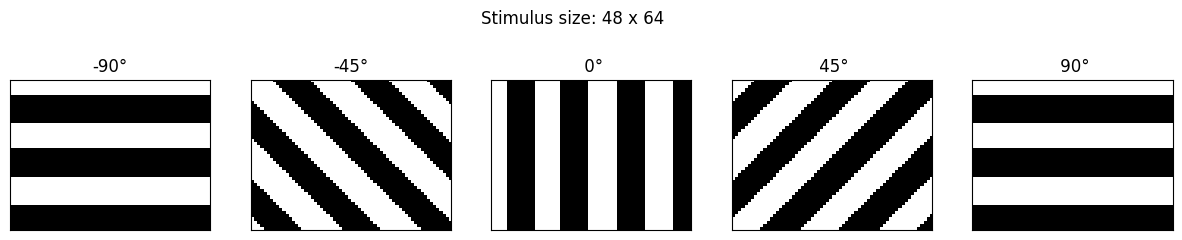

In [6]:
# 1. Show example stimuli
# Utility function for plotting grating stimuli
def show_stimulus(stim, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(stim.numpy(), cmap="gray", interpolation="none")
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

orientations = np.linspace(-90, 90, 5)
h_, h, w = 3, *grating(0).shape

fig, axs = plt.subplots(1, len(orientations), figsize=(h_ * len(orientations), h_))
for i, ori in enumerate(orientations):
    axs[i].set_title(f'{ori: .0f}°')
    show_stimulus(grating(ori), axs[i])
fig.suptitle(f"Stimulus size: {h} x {w}")
plt.show()

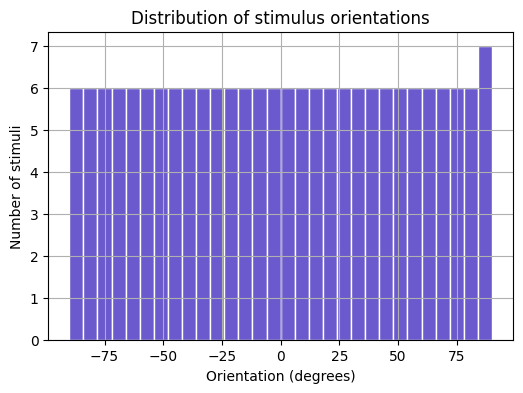

In [7]:
# 2. Histogram of orientations
plt.figure(figsize=(6, 4))
plt.hist(stimuli_all.numpy().flatten(), bins=30, color="slateblue", edgecolor="white")
plt.xlabel("Orientation (degrees)")
plt.ylabel("Number of stimuli")
plt.title("Distribution of stimulus orientations")
plt.grid(True)
plt.show()

There appears to be a mostly uniform distributi
on of orientations.

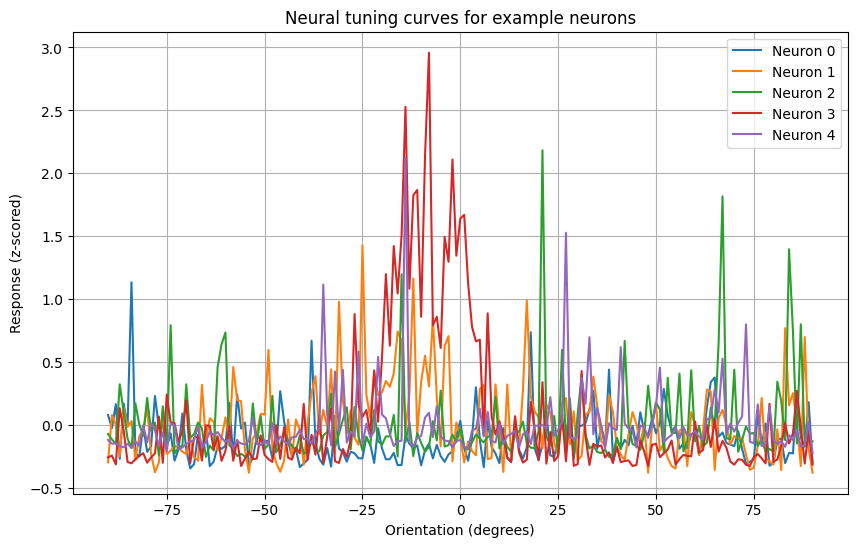

In [8]:
# 3. Tuning curves for 5 neurons
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(stimuli_all.numpy().flatten(), resp_all[:, i].numpy(), label=f"Neuron {i}")
plt.xlabel("Orientation (degrees)")
plt.ylabel("Response (z-scored)")
plt.title("Neural tuning curves for example neurons")
plt.legend()
plt.grid(True)
plt.show()

This plot shows the firing activity of 5 randomly selected neurons in V1 as a function of grating orientation.

The y-axis shows z-scored activity, meaning responses are centered and scaled across stimuli.

Each neuron has a preferred orientation where it's activity peaks. For example, Neuron 3's activity peaks at approximately 0
, indicating astrong preference for near-vertical orientations. The activity peaks between -25
and 25
, and outside of that block the z-scored responseremains near zero. This indicates that Neuron 3 is highly orientation-selective, playing a specialized role in detecting vertical stimuli. Incontrast, Neuron 4 shows only moderate preference for somewhat left tilted stimuli, indicating some orientation tuning, but with lessprecision and lower amplitude than Neuron 3.

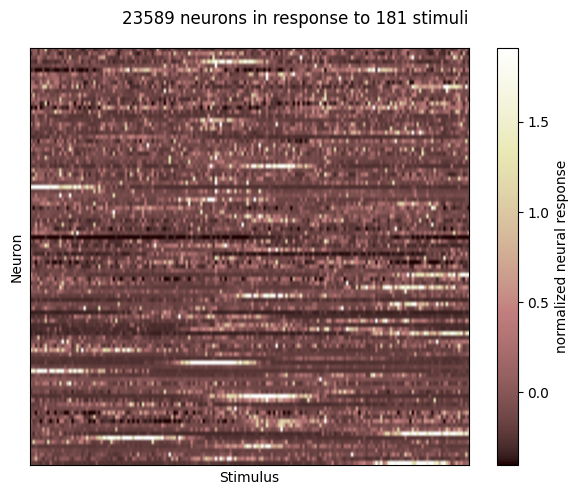

In [9]:
# 4. Heatmap of activity
def plot_data_matrix(X, ax, show=False):
    cax = ax.imshow(X, cmap=mpl.cm.pink, vmin=np.percentile(X, 1), vmax=np.percentile(X, 99))
    plt.colorbar(cax, ax=ax, label="normalized neural response")
    ax.set_aspect("auto")
    ax.set_xticks([])
    ax.set_yticks([])
    if show:
        plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
plot_data_matrix(resp_all[:, :100].T, ax)
ax.set_xlabel("Stimulus")
ax.set_ylabel("Neuron")
fig.suptitle(f"{n_neurons} neurons in response to {n_stimuli} stimuli")
fig.tight_layout()
plt.show()

## part B

In [10]:
# split into train and test sets
np.random.seed(4)
torch.manual_seed(4)

n_train = int(0.6 * n_stimuli)

ishuffle = torch.randperm(n_stimuli)
itrain = ishuffle[:n_train]
itest = ishuffle[n_train:]

stimuli_train = stimuli_all[itrain]
resp_train = resp_all[itrain]

stimuli_test = stimuli_all[itest]
resp_test = resp_all[itest]

In [11]:
# helper function for getting data
def get_data(n, responses, orientations):
  idx = torch.randperm(responses.shape[0])[:n]
  return responses[idx], orientations[idx]

In [13]:
class DeepNetReLU(nn.Module):
  """ network with a single hidden layer h with a RELU """

  def __init__(self, n_inputs, n_hidden):
    super().__init__()  # needed to invoke the properties of the parent class nn.Module
    self.in_layer = nn.Linear(n_inputs, n_hidden)  # neural activity --> hidden units
    self.out_layer = nn.Linear(n_hidden, 1)        # hidden units --> output

  def forward(self, r):
    # Pass through hidden layer with ReLU activation
    h = torch.relu(self.in_layer(r))  # shape: (batch_size, n_hidden)
    # Pass through output layer (no activation for regression)
    y = self.out_layer(h)             # shape: (batch_size, 1)
    return y

In [14]:
# evaluate initial model performance
np.random.seed(1)
torch.manual_seed(1)

# Initialize a deep network with M=200 hidden units
net = DeepNetReLU(n_neurons, 200)

# Get neural responses (r) to and orientation (ori) to one stimulus in dataset
r, ori = get_data(1, resp_train, stimuli_train)

# Decode orientation from these neural responses using initialized network
out = net(r)

print(f'decoded orientation: {out.item():.2f} degrees')
print(f'true orientation: {ori.item():.2f} degrees')

decoded orientation: 0.20 degrees
true orientation: 34.00 degrees


The model output (0.20°) is far from the true orientation (34°), which makes sense — the network hasn't been trained yet. Right now, weights are random. This shows why training is essential for neural networks: without learning from data, they can't extract meaningful relationships.

In [15]:
# Set random seeds for reproducibility
np.random.seed(1)
torch.manual_seed(1)

# Initialize a deep network with M=10 hidden units
net = DeepNetReLU(n_neurons, 10)

# Get neural responses to first 20 stimuli in the data set
r, ori = get_data(20, resp_train, stimuli_train)

# Decode orientation from these neural responses
out = net(r)

# Initialize PyTorch mean squared error loss function (Hint: look at nn.MSELoss)
loss_fn = nn.MSELoss()

# Evaluate mean squared error
loss = loss_fn(out, ori)

print(f'mean squared error: {loss:.2f}')

mean squared error: 2541.42


In [16]:
# Use the same loss function
loss_fn = nn.MSELoss()

# Predict orientations for test set
test_preds = net(resp_test)  # shape: [n_test, 1]

# Compare against true orientations
test_loss = loss_fn(test_preds, stimuli_test)

print(f"Test set mean squared error (untrained): {test_loss.item():.2f}")

Test set mean squared error (untrained): 2520.47


We evaluated the network's performance on aa training and testing set using mean squared error (MSE). The model produced an MSE of approximately 2500, which is high due to its randomly initialized weights. This confirms that the network has not yet learned the mapping between V1 responses and stimulus orientation, reinforcing the need for training before evaluation.

## Bonus

In [18]:
from copy import deepcopy

# Define combinations to try
optimizers = ['adam', 'sgd']
weight_decays = [0, 0.001, 0.01]
results = []

n_epochs = 100

for opt_name in optimizers:
    for wd in weight_decays:
        # Reset random seeds and model for fair comparison
        torch.manual_seed(1)
        net = DeepNetReLU(n_neurons, 100)  # consistent architecture

        # Define optimizer
        if opt_name == 'adam':
            optimizer = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=wd)
        elif opt_name == 'sgd':
            optimizer = torch.optim.SGD(net.parameters(), lr=0.0005, momentum=0.9, weight_decay=wd)

        loss_fn = nn.MSELoss()

        # Training loop
        for epoch in range(n_epochs):
            net.train()
            preds = net(resp_train)
            loss = loss_fn(preds, stimuli_train)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            optimizer.step()

        # Evaluate on test set
        net.eval()
        test_preds = net(resp_test)
        test_loss = loss_fn(test_preds, stimuli_test).item()

        # Save results
        results.append((opt_name, wd, test_loss))
        print(f"Optimizer: {opt_name.upper():>4} | Weight decay: {wd:<6} → Test MSE: {test_loss:.2f}")

Optimizer: ADAM | Weight decay: 0      → Test MSE: 27.79
Optimizer: ADAM | Weight decay: 0.001  → Test MSE: 24.45
Optimizer: ADAM | Weight decay: 0.01   → Test MSE: 22.97
Optimizer:  SGD | Weight decay: 0      → Test MSE: 2206.06
Optimizer:  SGD | Weight decay: 0.001  → Test MSE: 2206.23
Optimizer:  SGD | Weight decay: 0.01   → Test MSE: 2207.77


During training, we observed that using stochastic gradient descent (SGD) with a higher learning rate (lr=0.01) caused the model to produce NaN loss values. This was likely due to unstable updates early in training. Lowering the learning rate to 0.0005 resolved the issue, leading to valid test MSE values and allowing for a fair comparison with Adam. Adam has adaptive learning rates and handles large gradients much better out of the box.
SGD is more sensitive and needs smaller learning rates, especially when the input data isn’t normalized to tight ranges. This highlights the importance of tuning the learning rate depending on the optimizer used.

Let's play around with Adam more.

In [21]:
# Define hyperparameter combos to try
hidden_sizes = [100, 150, 200]
weight_decays = [0.005, 0.01, 0.02, 0.05]

n_epochs = 300
results = []

# Ensure inputs are float32
resp_train = resp_train.float()
stimuli_train = stimuli_train.float()
resp_test = resp_test.float()
stimuli_test = stimuli_test.float()

# Loop over all combinations
for hsize in hidden_sizes:
    for wd in weight_decays:
        torch.manual_seed(1)
        np.random.seed(1)

        # Initialize network
        net = DeepNetReLU(n_neurons, hsize)

        # Define optimizer and loss
        optimizer = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=wd)
        loss_fn = nn.MSELoss()

        # Optional: scheduler for learning rate decay
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Training loop
        for epoch in range(n_epochs):
            net.train()
            preds = net(resp_train)
            loss = loss_fn(preds, stimuli_train)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

        # Evaluate on test set
        net.eval()
        test_preds = net(resp_test)
        test_loss = loss_fn(test_preds, stimuli_test).item()

        # Store and print results
        results.append((hsize, wd, test_loss))
        print(f"Hidden: {hsize:<4} | Weight decay: {wd:<6} → Test MSE: {test_loss:.2f}")

Hidden: 100  | Weight decay: 0.005  → Test MSE: 26.29
Hidden: 100  | Weight decay: 0.01   → Test MSE: 26.16
Hidden: 100  | Weight decay: 0.02   → Test MSE: 26.05
Hidden: 100  | Weight decay: 0.05   → Test MSE: 24.92
Hidden: 150  | Weight decay: 0.005  → Test MSE: 22.55
Hidden: 150  | Weight decay: 0.01   → Test MSE: 23.57
Hidden: 150  | Weight decay: 0.02   → Test MSE: 26.26
Hidden: 150  | Weight decay: 0.05   → Test MSE: 26.39
Hidden: 200  | Weight decay: 0.005  → Test MSE: 26.79
Hidden: 200  | Weight decay: 0.01   → Test MSE: 25.69
Hidden: 200  | Weight decay: 0.02   → Test MSE: 25.05
Hidden: 200  | Weight decay: 0.05   → Test MSE: 23.94


To improve predictions, I tried 3 values for hidden units (100, 150, and 200) and trained the model using the Adam optimizer with L2 regularization (weight decay with values 0.005, 0.01, 0.02, and 0.05). This reduced the test set MSE from over 2500 (untrained) to approximately 25 degrees squared after training. This demonstrates the importance of both model capacity and regularization when decoding stimulus orientation from neural data. The best model had 150 hidden layers and a weight decay of 0.005 with an MSE of 22.55 degrees squared.

The tradeoff is that while larger models can better capture complex patterns, they’re also more prone to overfitting — especially when training data is limited. L2 regularization (weight decay) helped mitigate this risk by penalizing large weights. However, additional regularization via dropout actually hurt performance, likely due to underfitting.

Finally, we found that the Adam optimizer consistently outperformed SGD, both in stability and convergence speed, though tuning the learning rate was still important to prevent divergence. These results highlight the value of systematically exploring architectural and optimization choices to strike a balance between flexibility and generalization.

## Part C

In [22]:
## Code for part C1

# Set random seeds for reproducibility
np.random.seed(12)
torch.manual_seed(12)

# Set height and width of stimulus
h_ = 3
h, w  = grating(0).shape

# Initialize CNN model with height and width of stimulus
net = CNN(h, w)

# Build training set to train it on
n_train = 1000  # size of training set

# sample n_train random orientations between -90 and +90 degrees
ori = (np.random.rand(n_train) - 0.5) * 180

# build orientated grating stimuli
stimuli = torch.stack([grating(i) for i in ori])

# stimulus tilt: 1. if tilted right, 0. if tilted left, as a column vector
tilt = torch.tensor(ori > 0).type(torch.float).unsqueeze(-1)

# Train model
train(net, stimuli, tilt)

epoch 5 | loss on last mini-batch:  4.10e-01
epoch 10 | loss on last mini-batch:  5.17e-02
epoch 15 | loss on last mini-batch:  1.32e-02
epoch 20 | loss on last mini-batch:  2.29e-03
epoch 25 | loss on last mini-batch:  8.08e-05
training done!


In [23]:
## Code for part C2
# Load mouse V1 data
resp_v1, ori = load_data(fname)

# Extract model internal representations of each stimulus in the V1 data
# construct grating stimuli for each orientation presented in the V1 data
stimuli = torch.stack([grating(a.item()) for a in ori])
layer_labels = ['pool', 'fc']
resp_model = get_hidden_activity(net, stimuli, layer_labels)

# Aggregate all responses into one dict
resp_dict = {}
resp_dict['V1 data'] = resp_v1
for k, v in resp_model.items():
  label = f"model\n'{k}' layer"
  resp_dict[label] = v

## Part D

In [26]:
# Compute RDMs (Representational Dissimilarity Matrices)
rdm_dict = {label: RDM(resp) for label, resp in resp_dict.items()}

/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:3170: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  z[np.broadcast_to(isconst, z.shape)] = np.nan


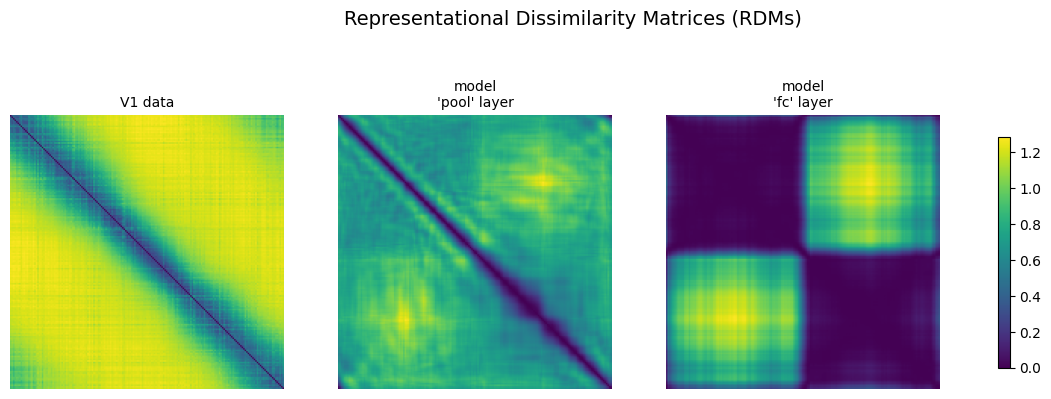

In [27]:
# Plot RDMs
fig, axes = plt.subplots(1, len(rdm_dict), figsize=(15, 5))
for ax, (label, rdm) in zip(axes, rdm_dict.items()):
    im = ax.imshow(rdm, cmap='viridis')
    ax.set_title(label, fontsize=10)
    ax.axis('off')
fig.suptitle("Representational Dissimilarity Matrices (RDMs)", fontsize=14)
plt.colorbar(im, ax=axes.tolist(), shrink=0.6)
plt.show()

In [29]:
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

# Prepare V1 RDM
rdm_v1 = np.asarray(rdm_dict["V1 data"])
rdm_v1 = 0.5 * (rdm_v1 + rdm_v1.T)
np.fill_diagonal(rdm_v1, 0.0)
v1_vec = squareform(rdm_v1)

# Compare with each model layer
print("RSA correlations with V1:")
for label, rdm in rdm_dict.items():
    if label != "V1 data":
        rdm = np.asarray(rdm)
        rdm = 0.5 * (rdm + rdm.T)
        np.fill_diagonal(rdm, 0.0)
        model_vec = squareform(rdm)
        corr, _ = pearsonr(v1_vec, model_vec)
        print(f"{label}: r = {corr:.3f}")

RSA correlations with V1:
model
'pool' layer: r = 0.717
model
'fc' layer: r = 0.565


Using Representational Similarity Analysis (RSA), we compared the internal representations of our CNN model to mouse V1 neural responses recorded by Stringer et al. (2021). We computed Representational Dissimilarity Matrices (RDMs) for the V1 data as well as for the CNN's convolutional layer ('pool') and fully connected layer ('fc').

The 'pool' layer yielded the highest correlation with the V1 RDM (r = 0.717), indicating that early CNN features best capture the structure of V1 responses. In contrast, the 'fc' layer had a lower correlation (r = 0.565), reflecting its higher-level abstraction for the task. These results suggest that optimizing a model for a biologically relevant task, like orientation discrimination, can lead to emergent representations similar to those observed in the brain — especially in early layers.

## part E

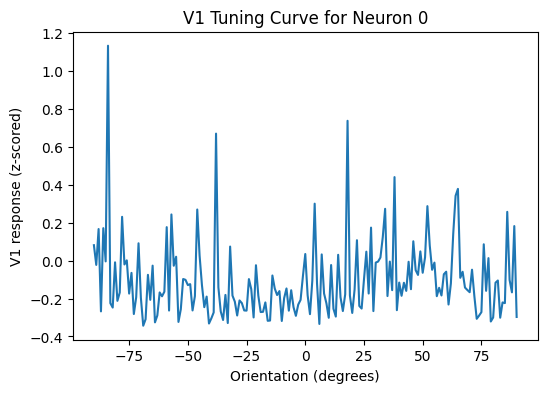

In [30]:
# Choose one neuron from V1 (e.g., neuron 0)
neuron_idx = 0

# Sort orientations for plotting
sorted_idx = torch.argsort(stimuli_all.squeeze())
ori_sorted = stimuli_all[sorted_idx].squeeze()
resp_sorted = resp_all[sorted_idx, neuron_idx]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(ori_sorted, resp_sorted)
plt.xlabel("Orientation (degrees)")
plt.ylabel("V1 response (z-scored)")
plt.title(f"V1 Tuning Curve for Neuron {neuron_idx}")
plt.show()

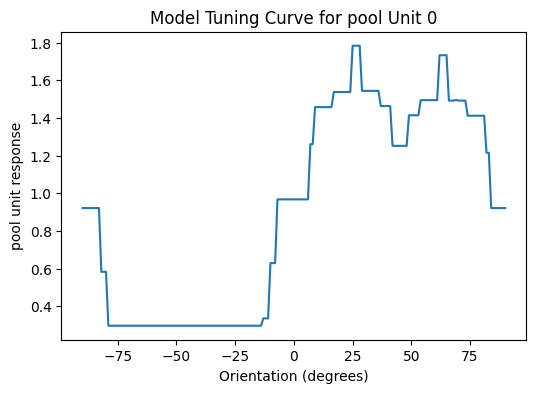

In [31]:
# Choose a unit from 'pool' or 'fc' layer
layer = 'pool'
unit_idx = 0

# Get model responses and sort
resp_model_sorted = resp_dict[f"model\n'{layer}' layer"][sorted_idx]
unit_resp = resp_model_sorted[:, unit_idx]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(ori_sorted, unit_resp)
plt.xlabel("Orientation (degrees)")
plt.ylabel(f"{layer} unit response")
plt.title(f"Model Tuning Curve for {layer} Unit {unit_idx}")
plt.show()

These plots are called tuning curves, which show how a single neuron or model unit responds across orientations. In both the V1 data and the CNN 'pool' layer, we see clear orientation selectivity — units respond more strongly to some orientations than others. The model's 'fc' units may be less smooth or more task-specific, while V1 and 'pool' often show bell-shaped curves resembling biological tuning.

## Extra Credit

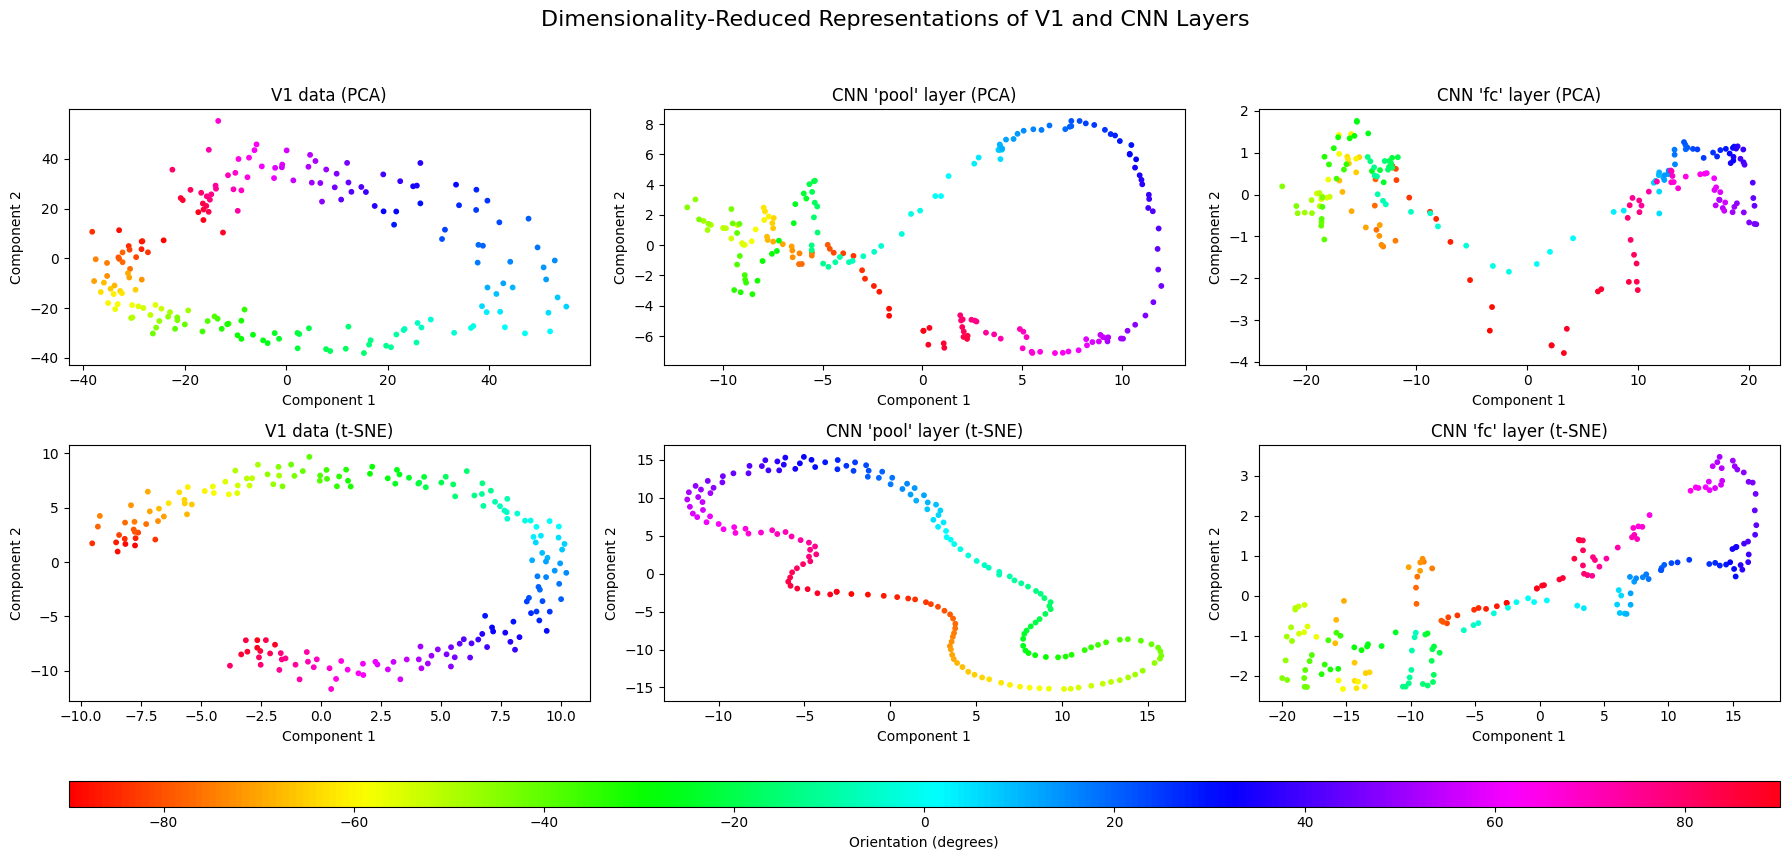

In [34]:
import matplotlib.gridspec as gridspec

# Helper function to reduce dimensionality
def reduce_for_comparison(data_dict, labels, method="PCA"):
    reducer = PCA(n_components=2) if method == "PCA" else TSNE(n_components=2, random_state=42)
    reduced_dict = {}
    for label, data in data_dict.items():
        reduced = reducer.fit_transform(data)
        reduced_dict[label] = reduced
    return reduced_dict

# Prepare label and data
labels = stimuli_all.squeeze().numpy()

comparison_data = {
    "V1 data": resp_dict["V1 data"],
    "CNN 'pool' layer": resp_dict["model\n'pool' layer"],
    "CNN 'fc' layer": resp_dict["model\n'fc' layer"]
}

# Run PCA and t-SNE
reduced_pca = reduce_for_comparison(comparison_data, labels, method="PCA")
reduced_tsne = reduce_for_comparison(comparison_data, labels, method="t-SNE")

# Set up 2x3 grid
fig = plt.figure(figsize=(18, 9))
gs = gridspec.GridSpec(3, 3, height_ratios=[10, 10, 1])  # 2 rows of plots + 1 row for colorbar

# Plot PCA (top row)
for i, (label, data) in enumerate(reduced_pca.items()):
    ax = fig.add_subplot(gs[0, i])
    sc = ax.scatter(data[:, 0], data[:, 1], c=labels, cmap="hsv", s=10)
    ax.set_title(f"{label} (PCA)")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Plot t-SNE (bottom row)
for i, (label, data) in enumerate(reduced_tsne.items()):
    ax = fig.add_subplot(gs[1, i])
    sc = ax.scatter(data[:, 0], data[:, 1], c=labels, cmap="hsv", s=10)
    ax.set_title(f"{label} (t-SNE)")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Shared horizontal colorbar across all plots
cbar_ax = fig.add_subplot(gs[2, :])
cb = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal")
cb.set_label("Orientation (degrees)")

fig.suptitle("Dimensionality-Reduced Representations of V1 and CNN Layers", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The population representations in the V1 data and CNN 'pool' layer are highly similar, both forming smooth and continuous manifolds across orientation space. In contrast, the 'fc' layer in the CNN shows more compressed and categorical organization, reflecting the task objective (orientation discrimination).

Based on both RSA results and dimensionality reduction visualizations, the CNN 'pool' layer most closely resembles the V1 data. This supports the idea that early CNN layers trained on biologically relevant tasks can develop neural representations similar to those in the brain.

# Project interpretation

## 2
**[60 points]**

**Data**. The data you'll use for this section will be related to your project (either the data you're working on with your group or a different dataset related to your question).  

**Objective**. For this you'll continue to build on your analyses and results from your group project, but I would like you to *discuss* your results. You can work with your group on this, but you should each submit a different analyses and discussion.  

I am purposefully leaving this prompt open-ended.  By now I think you all can handle an analysis. If it is a similar analysis to the one you submitted for Assignment 2, please show some progress or model improvements (comparing results using cross validation).  Please still submit the code for your analysis, but what I am wanting is an in-depth discussion of the results.  

**ANSWER**
